# RQ3 Analysis (scalability of CRUD operations)

In [6]:
def shorten_x_axis_labels(ax):
    labels = [t.get_text() for t in ax.get_xticklabels()]

    new_labels = []
    for l in labels:
        try:
            val = float(l)

            if val >= 1_000_000:
                new_labels.append(f"{int(val/1_000_000)}M")
            elif val >= 1_000:
                new_labels.append(f"{int(val/1_000)}K")
            else:
                new_labels.append(str(int(val)))

        except:
            new_labels.append(l)

    ax.set_xticklabels(new_labels, rotation=0)

## Create Operations


=== Loading ApplauseDsl ===

=== Loading AthenaDSL ===

=== Loading AtsDsl ===

=== Loading business ===

=== Loading CoreDsl ===

=== Loading CssExtDsl ===

=== Loading DialogScript ===

=== Loading environment ===

=== Loading erlang ===

=== Loading esb ===

=== Loading EventOrientedLanguage ===

=== Loading FlatQVT ===

=== Loading FractalItf ===

=== Loading Glsl ===

=== Loading hockeyleague ===

=== Loading Iptables ===

=== Loading java5 ===

=== Loading JavaVMTypes ===

=== Loading LLVM_IR ===

=== Loading MDD ===

=== Loading modelica ===

=== Loading NetModel ===

=== Loading OseeDsl ===

=== Loading reviews ===

=== Loading RobotTask ===

=== Loading SqliteModel ===

=== Loading StaticScript ===

=== Loading timing-diagram ===

=== Loading Transformation ===

=== Loading widget ===


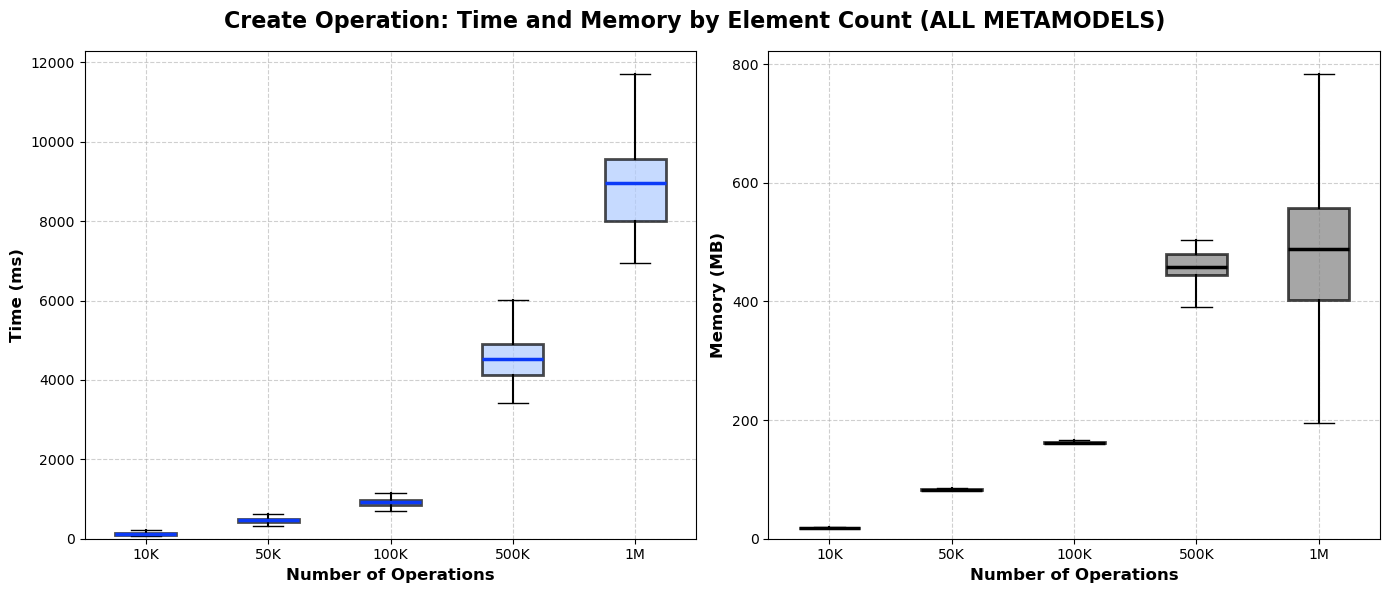

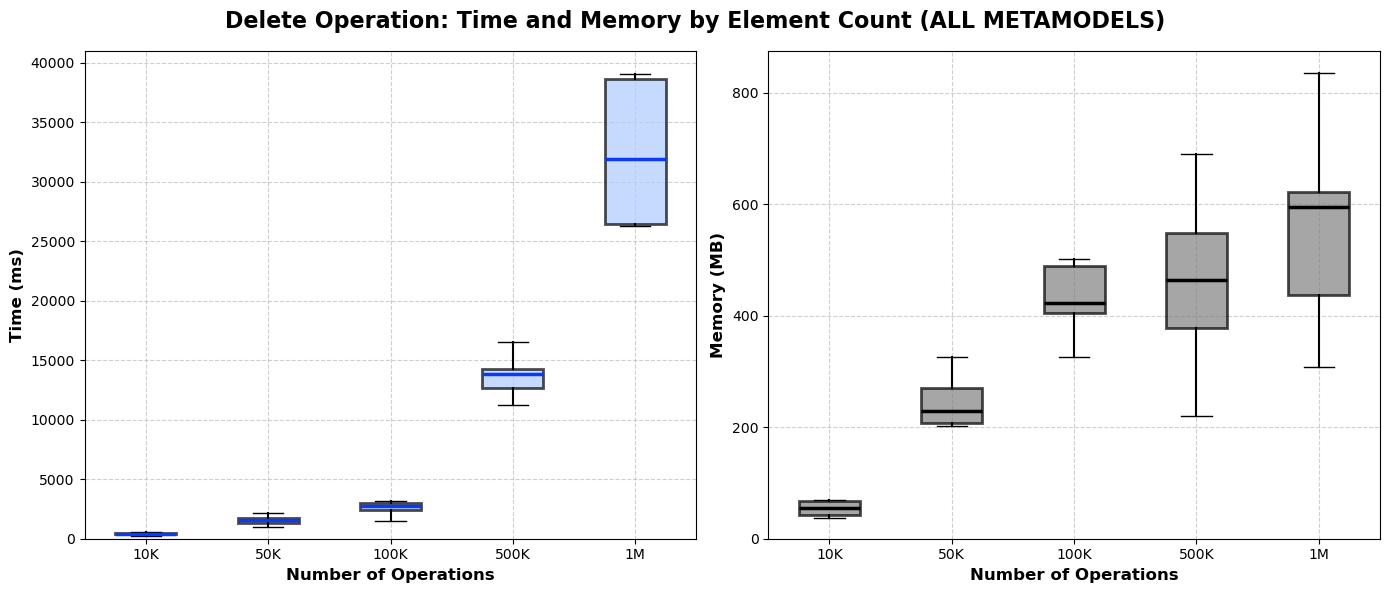

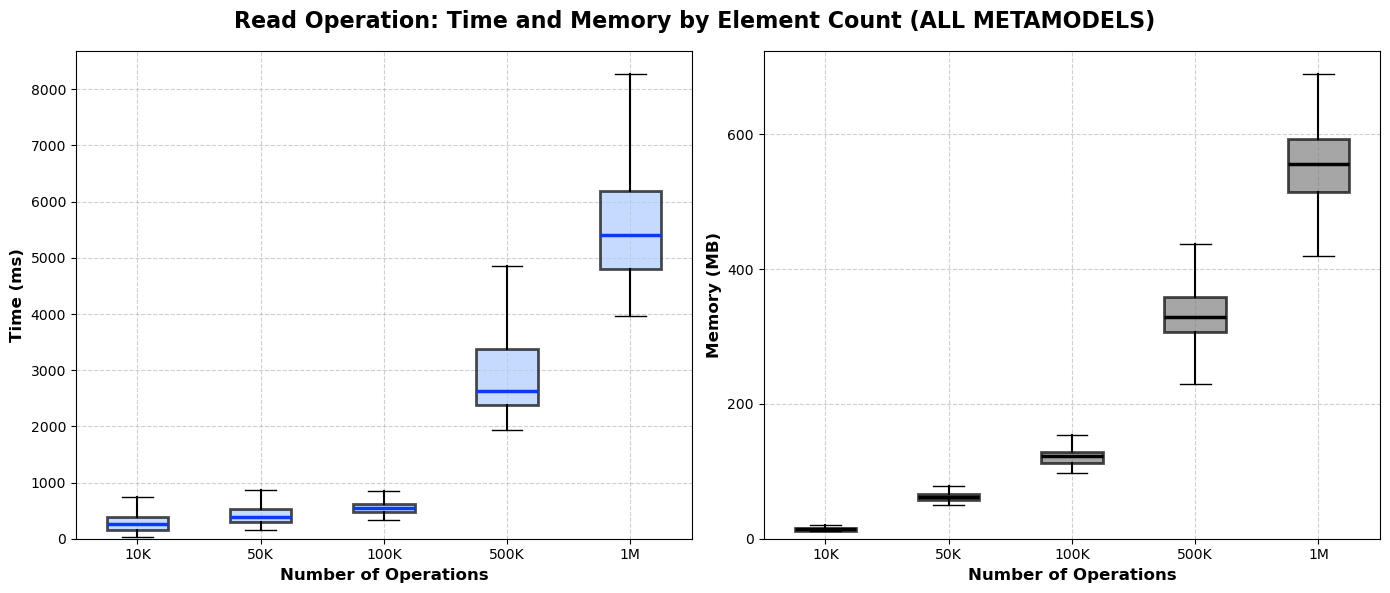

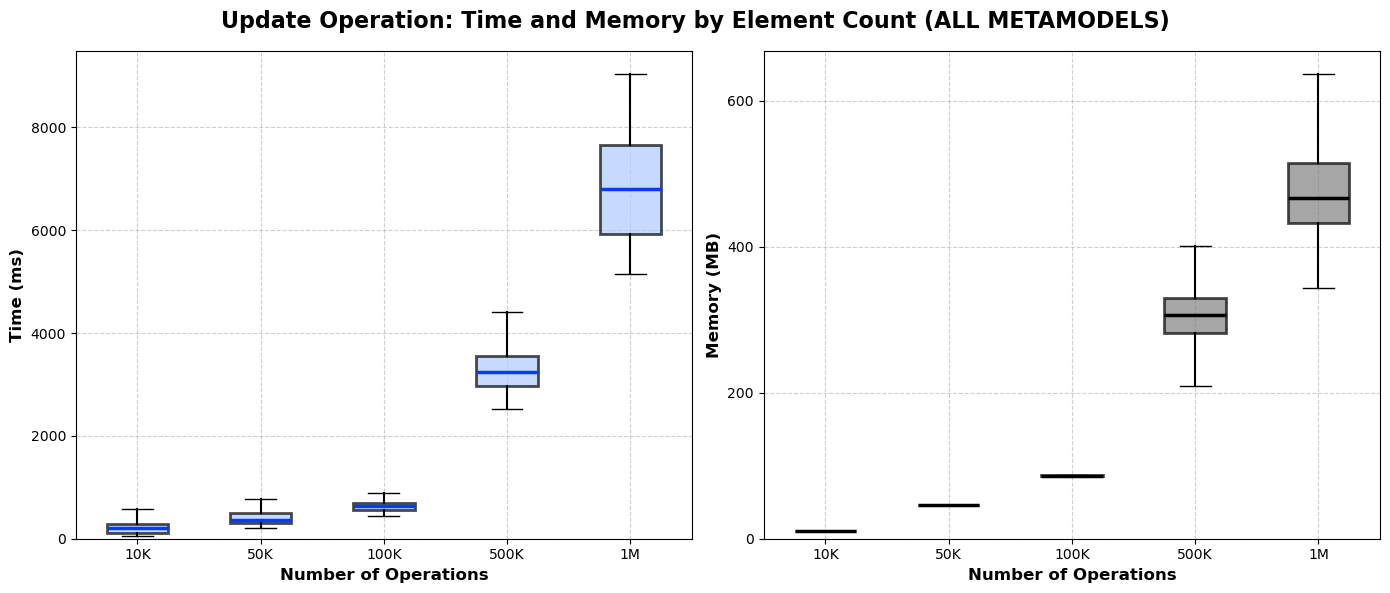

In [7]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

BASE_FOLDER = "../results/RQ3GenModels"

group_col = "element_count"
pattern = re.compile(r"(.+)_run_\d+\.csv")


def plot_operation(df, op_name, metamodel_name):
    #df["time"] = df["time"] / 1000  
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # -------- TIME --------
    df.boxplot(
        column="time",
        by=group_col,
        ax=axes[0],
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor="#AFCBFF", color="black", linewidth=2, alpha=0.7),
        medianprops=dict(color="#0B3AF7", linewidth=2.5),
        whiskerprops=dict(color="black", linewidth=1.5),
    )

    axes[0].set_title("")
    axes[0].set_xlabel("Number of Operations", fontsize=12, fontweight="bold")
    axes[0].set_ylabel("Time (ms)", fontsize=12, fontweight="bold")
    axes[0].grid(True, linestyle="--", alpha=0.6)
    axes[0].set_ylim(bottom=0)

    # -------- MEM --------
    df.boxplot(
        column="mem",
        by=group_col,
        ax=axes[1],
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor="gray", color="black", linewidth=2, alpha=0.7),
        medianprops=dict(color="black", linewidth=2.5),
        whiskerprops=dict(color="black", linewidth=1.5),
    )

    axes[1].set_xlabel("Number of Operations", fontsize=12, fontweight="bold")
    axes[1].set_ylabel("Memory (MB)", fontsize=12, fontweight="bold")

    axes[1].yaxis.set_major_locator(mticker.MultipleLocator(200 * 1024))
    axes[1].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{int(x / 1024)}")
    )

    axes[1].grid(True, linestyle="--", alpha=0.6)
    axes[1].set_ylim(bottom=0)
    axes[1].set_title("")

    shorten_x_axis_labels(axes[0])
    shorten_x_axis_labels(axes[1])
    axes[0].set_ylim(bottom=0)
    axes[1].set_ylim(bottom=0)

    plt.suptitle(
        f"{op_name} Operation: Time and Memory by Element Count ({metamodel_name})",
        fontsize=16,
        fontweight="bold",
    )

    plt.tight_layout()

    plt.show()


# ---------------- main loop (MODIFIED ONLY PART) ----------------

operations = {}

for metamodel in os.listdir(BASE_FOLDER):
    folder_path = os.path.join(BASE_FOLDER, metamodel)

    if not os.path.isdir(folder_path):
        continue

    print(f"\n=== Loading {metamodel} ===")

    for file in os.listdir(folder_path):
        if not file.endswith(".csv"):
            continue

        match = pattern.match(file)
        if not match:
            continue

        op = match.group(1)

        df = pd.read_csv(os.path.join(folder_path, file))
        df["metamodel"] = metamodel  # kept for traceability (not used in plot)

        operations.setdefault(op, []).append(df)


for op, dfs in operations.items():
    full_df = pd.concat(dfs, ignore_index=True)

    # all metamodels combined
    plot_operation(full_df, op, "ALL METAMODELS")

In [8]:
import os
import re
import pandas as pd

BASE_FOLDER = "../results/RQ3GenModels"

group_col = "element_count"
pattern = re.compile(r"(.+)_run_\d+\.csv")


# ---- Helper ----
def remove_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return series[(series >= q1 - 1.5 * iqr) & (series <= q3 + 1.5 * iqr)]


# ---- LOAD DATA ----
operations = {}

for metamodel in os.listdir(BASE_FOLDER):
    folder_path = os.path.join(BASE_FOLDER, metamodel)

    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):
        if not file.endswith(".csv"):
            continue

        match = pattern.match(file)
        if not match:
            continue

        op = match.group(1)

        df = pd.read_csv(os.path.join(folder_path, file))
        df["metamodel"] = metamodel

        operations.setdefault(op, []).append(df)


# ---- ANALYSIS ----
for op, dfs in operations.items():
    print("\n===================================================")
    print(f"OPERATION: {op}")
    print("===================================================\n")

    df = pd.concat(dfs, ignore_index=True)

    # ---- GLOBAL ----
    print("---- GLOBAL STATS ----")
    for metric in ["time", "mem"]:
        s = df[metric]
        print(f"{metric.upper()}: mean={s.mean():.4f}, median={s.median():.4f}, std={s.std():.4f}, max={s.max():.4f}")
    print()

    # ---- GLOBAL (OUTLIERS REMOVED) ----
    print("---- GLOBAL (OUTLIERS REMOVED) ----")
    for metric in ["time", "mem"]:
        s = remove_outliers(df[metric])
        print(f"{metric.upper()}: mean={s.mean():.4f}, std={s.std():.4f}, count={len(s)}")
    print()

    # ---- PER ELEMENT COUNT ----
    print("---- PER ELEMENT COUNT ----")
    grouped = df.groupby(group_col)

    for val, group in grouped:
        t_mean = remove_outliers(group["time"]).mean()
        m_mean = remove_outliers(group["mem"]).mean()
        print(f"{group_col}={val}: time_mean={t_mean:.4f}, mem_mean={m_mean:.4f}")
    print()

    # ---- CORRELATION ----
    print("---- CORRELATION ----")
    corr_time = df[group_col].corr(df["time"])
    corr_mem = df[group_col].corr(df["mem"])
    print(f"{group_col} vs time: {corr_time:.4f}")
    print(f"{group_col} vs mem:  {corr_mem:.4f}")
    print()

    # ---- PER METAMODEL ----
    print("---- PER METAMODEL ----")
    grouped_meta = df.groupby("metamodel")

    for name, group in grouped_meta:
        t_mean = remove_outliers(group["time"]).mean()
        m_mean = remove_outliers(group["mem"]).mean()
        print(f"{name}: time_mean={t_mean:.4f}, mem_mean={m_mean:.4f}, samples={len(group)}")
    print()

    # ---- WORST CASES ----
    print("---- TOP 3 WORST CASES ----")

    print("\nSlowest:")
    print(df.nlargest(3, "time")[["metamodel", group_col, "time"]])

    print("\nMost memory:")
    print(df.nlargest(3, "mem")[["metamodel", group_col, "mem"]])

    print("\n")


OPERATION: Create

---- GLOBAL STATS ----
TIME: mean=14746.6847, median=913.0000, std=113039.1250, max=2240288.0000
MEM: mean=246381.4678, median=165888.0000, std=205189.5235, max=968858.0000

---- GLOBAL (OUTLIERS REMOVED) ----
TIME: mean=2895.8497, std=3340.5231, count=4386
MEM: mean=246381.4678, std=205189.5235, count=4500

---- PER ELEMENT COUNT ----
element_count=10000: time_mean=111.3538, mem_mean=18818.8618
element_count=50000: time_mean=461.0925, mem_mean=84483.7917
element_count=100000: time_mean=907.8189, mem_mean=166399.8163
element_count=500000: time_mean=4462.6108, mem_mean=472002.8029
element_count=1000000: time_mean=8824.2425, mem_mean=487868.4036

---- CORRELATION ----
element_count vs time: 0.0842
element_count vs mem:  0.8742

---- PER METAMODEL ----
ApplauseDsl: time_mean=3108.4933, mem_mean=262878.9133, samples=150
AthenaDSL: time_mean=41159.3605, mem_mean=236781.5200, samples=150
AtsDsl: time_mean=2704.7933, mem_mean=209857.2933, samples=150
CoreDsl: time_mean=266